In [18]:
# Decoding 
%reload_ext autoreload


# Pool data across session and animals
import argparse
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import seaborn as sns
import pickle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    silhouette_score,
    adjusted_rand_score,
    silhouette_samples,
    confusion_matrix,
)
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, KMeans
from sklearn.model_selection import KFold, LeaveOneOut, train_test_split,  cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.kernel_ridge import KernelRidge
from sklearn import linear_model
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier

from patsy import (
    ModelDesc,
    EvalEnvironment,
    Term,
    EvalFactor,
    LookupFactor,
    dmatrices,
    INTERCEPT,
)
from statsmodels.distributions.empirical_distribution import ECDF
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.colorbar as colorbar
import sys
import utils_py3 as ut

import importlib
import s2p_utils.processing_utils
importlib.reload(s2p_utils.processing_utils)
from s2p_utils.data_loader import DataLoader
from s2p_utils.processing_utils import (
    extract_events,
    get_corrected_F,
    normalize_signal,
    extract_Fave_around_events,
    extract_F_around_events,
    reorder_clusters,
    filter_trials_by_minITI,
    extract_patterns_for_decoding,
    get_animal_decoding_dict,
    do_time_resolved_decoding,
    do_time_window_decoding,
)

import plot_utils
importlib.reload(plot_utils)
from plot_utils import (
    plot_decoding_accuracy_across_time
)

logger = logging.getLogger(__name__)

In [2]:
def plot_time_window_decoding(accuracy, accuracy_chance, time_windows):
    """
    Plot decoding accuracy across multiple time windows.

    Args:
        accuracy (ndarray): shape (n_animals, n_time_windows)
        accuracy_chance (ndarray): shape (n_animals, n_time_windows)
        time_windows (list of list): e.g., [[0,1,2], [3,4,5], ...]
    
    Returns:
        fig (matplotlib Figure)
    """
    mean_real = np.nanmean(accuracy, axis=0)
    sem_real = np.nanstd(accuracy, axis=0) / np.sqrt(accuracy.shape[0])
    mean_chance = np.nanmean(accuracy_chance, axis=0)
    sem_chance = np.nanstd(accuracy_chance, axis=0) / np.sqrt(accuracy_chance.shape[0])

    # Paired t-test across animals for each window
    p_values = [stats.ttest_rel(accuracy[:, t], accuracy_chance[:, t]).pvalue for t in range(accuracy.shape[1])]
    significance = ['*' if p < 0.05 else '' for p in p_values]

    fig, ax = plt.subplots(figsize=(5, 3))
    x = np.arange(len(time_windows))

    ax.errorbar(x, mean_real, yerr=sem_real, color='forestgreen', marker='o', linewidth=1, label='Real')
    ax.errorbar(x, mean_chance, yerr=sem_chance, color='gray', linestyle='--', marker='o', linewidth=1, label='Chance')

    for i, sig in enumerate(significance):
        if sig:
            ax.text(i, max(mean_real[i], mean_chance[i]) + 0.025, sig, ha='center', va='bottom', fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{w[0]}–{w[-1]}' for w in time_windows], rotation=0)
    ax.set_xlabel('Time window from cue (bins)', fontsize=10)
    ax.set_ylabel('Decoding accuracy', fontsize=10)
    # ax.set_ylim([0.4, 0.65])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.2), frameon=False)
    fig.tight_layout()
    return fig


def plot_time_window_decoding_bar(accuracy, accuracy_chance, time_windows):
    """
    Plot decoding accuracy for multiple time windows using bar plots.

    Args:
        accuracy (np.ndarray): shape (n_animals, n_time_windows)
        accuracy_chance (np.ndarray): same shape
        time_windows (list of lists): each sublist is a list of time bin indices
        offset (int): time bin offset to center time labels around cue onset
    """
    mean_real = np.nanmean(accuracy, axis=0)
    sem_real = np.nanstd(accuracy, axis=0) / np.sqrt(accuracy.shape[0])
    mean_chance = np.nanmean(accuracy_chance, axis=0)
    sem_chance = np.nanstd(accuracy_chance, axis=0) / np.sqrt(accuracy_chance.shape[0])

    # Paired t-tests
    p_values = [stats.ttest_rel(accuracy[:, t], accuracy_chance[:, t]).pvalue for t in range(accuracy.shape[1])]
    significance = ['*' if p < 0.05 else '' for p in p_values]

    # Generate x-axis labels from raw time windows
    labels = []
    for win in time_windows:
        if len(win) == 1:
            labels.append(str(win[0]))
        else:
            labels.append(f"{win[0]}–{win[-1]}")

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 3.5))

    # Bar plots
    ax.bar(x - width/2, mean_real, width, yerr=sem_real, label='Real', color='forestgreen', capsize=4)
    ax.bar(x + width/2, mean_chance, width, yerr=sem_chance, label='Chance', color='gray', alpha=0.7, capsize=4)

    # Significance markers
    for i, sig in enumerate(significance):
        if sig:
            height = max(mean_real[i] + sem_real[i], mean_chance[i] + sem_chance[i]) + 0.02
            ax.text(i, height, sig, ha='center', va='bottom', fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Time window bins (s from cue))', fontsize=10)
    ax.set_ylabel('Decoding accuracy', fontsize=10)
    ax.set_ylim([0.4, 1.0])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper right')

    fig.tight_layout()
    return fig

In [3]:
# 1. Initialize parameters
framerate = 5
trial_types = ["CS1+", "CS2+", "CS3-"]
pre_cue_window = 3
post_cue_window = 17
delay_to_reward = 3
# min_cell_prob = 0.5
# neucoeff = 0.7
# cell_threshold = 10
data_dir = "Z:\\2p\\experiment1"

imaging_system = "INSS"
learning_stage = "early"

# Set animals and days for early and late learning
if learning_stage == "early":
    result_dir = "Z:\\2p\\experiment1\\population_data\\early learning\\"
    animal_list = [
        # "MZ_CA1_WD_F3",
        # "MZ_CA1_WD_M4",
        "MZ_CA1_WD_M5",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55",
    ]
    daylist = [1, 1, 1, 1, 1, 1, 1, 1]
    subtrials = 'first10'
    
elif learning_stage == 'intermediate':
    result_dir = "Z:\\2p\\experiment1\\population_data\\intermediate learning"
    animal_list = [
            "MZ_CA1_WD_F3",
            "MZ_CA1_WD_M4",
            "MZ_CA1_WD_M5",
            "MZ_CA1_WD_M6",
            "MZ_CA1_WD_M7",
            "MZ_CA1_WD_M8",
            "MZ_CA1_WD_JB_54",
            "MZ_CA1_WD_JB_55"
        ] 
    daylist = [3, 2, 3, 3, 3, 2, 3, 8]   
    subtrials = 'all'
    
elif learning_stage == "late":
    result_dir = "Z:\\2p\\experiment1\\population_data\\late learning\\all trials"
    animal_list = [
        "MZ_CA1_WD_F3",
        "MZ_CA1_WD_M4",
        "MZ_CA1_WD_M5",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55"
    ]   
    # daylist = [7, 5, 6, 6, 5, 6, 8, 12] # before
    # daylist = [7, 5, 5, 5, 6, 6, 8, 12]
    daylist = [7, 5, 6, 6, 6, 6, 8, 12]
    subtrials = 'all'
    
    
# Load time bins for patterns, do all the time for now, can slice later 
seed = 42
total_bins = slice(0, (pre_cue_window + post_cue_window)*framerate)  # time bins to use for decoding
total_bins_length = total_bins.stop - total_bins.start

In [5]:
def get_deep_shape(lst):
    # Recursive function to get shape at each level
    if isinstance(lst, list):
        first_level = len(lst)
        second_level = [len(item) if isinstance(item, list) else 0 for item in lst]
        third_level = []
        for item in lst:
            if isinstance(item, list) and len(item) > 0:
                third_level.append([len(cell) if isinstance(cell, list) else 0 for cell in item])
            else:
                third_level.append([])
        return {
            'cs_types': first_level,
            'trials_per_cs': second_level,
            'cells_per_trial': third_level
        }
    else:
        return 'Input is not a list'

In [6]:
# 2. Load decoding patterns and labels, if not there, create them
pattern_path = os.path.join(result_dir, "decoding_patterns.pickle")
label_path = os.path.join(result_dir, "decoding_labels.pickle")

if os.path.exists(pattern_path):
    with open(pattern_path, "rb") as f:
        patterns = pickle.load(f)
    with open(label_path, "rb") as f:
        labels = pickle.load(f)    
else:
    patterns = {}
    labels = {}
    for ia, animal in enumerate(animal_list):
        day = daylist[ia]
        animal_dir = os.path.join(data_dir, animal, "d"+str(day))
        file_dir = os.path.join(animal_dir, "files")
        
        Fcorr_5hz = np.load(os.path.join(file_dir, "F_5hz.npy"), allow_pickle=True)
        new_im_ts = np.load(os.path.join(file_dir, "timestamps_5hz.npy"), allow_pickle=True)
        
        # # Extract all event time points from new event_df
        num_planes = Fcorr_5hz.shape[0]
        data_loader = DataLoader(animal_dir, num_planes, 0, imaging_system)

        event_df = pd.read_pickle(os.path.join(file_dir, "event_df.pkl"))  # Arduino
        [licks, CS1, CS2, CS3, sucrose, umami] = extract_events(event_df)
        allCS = filter_trials_by_minITI([CS1, CS2, CS3], post_cue_window)
            
        # # Normalize signal
        # Fcorr_norm_down = normalize_signal(
        #     Fcorr_5hz, num_planes, "median"
        # )  # can be z_score, median, robust_z_score

        # # Extract binned Fcorr around pre and post cue window for each trial, shape is nCS types x ntrials x nCell x nbins, binsize in ms
        Fcorr_around_cue = extract_F_around_events(
            allCS,
            Fcorr_5hz,
            new_im_ts,
            num_planes,
            pre_cue_window,
            post_cue_window,
            binsize=1000,
            framerate=framerate,
        )
        
        # # Baseline subtraction if needed
        # for cs in range(len(trial_types)):
        #     trial_specific_F = np.array(Fcorr_around_cue[cs])
        #     baseline = np.nanmean(trial_specific_F[:, :, :pre_cue_window*framerate], axis=2, keepdims=True)
        #     Fcorr_around_cue[cs] = trial_specific_F - baseline
        
        X, y = extract_patterns_for_decoding(Fcorr_around_cue, total_bins)
        patterns[animal] = X
        labels[animal] = y        

    with open(pattern_path, "wb") as f:
        pickle.dump(patterns, f)
    with open(label_path, "wb") as f:
        pickle.dump(labels, f)

In [7]:
pattern_path = os.path.join(result_dir, "decoding_patterns.pickle")
label_path = os.path.join(result_dir, "decoding_labels.pickle")

with open(pattern_path, "wb") as f:
    pickle.dump(patterns, f)
with open(label_path, "wb") as f:
    pickle.dump(labels, f)

In [8]:
# set time bins
decoding_time_window = np.arange(0, 20)  # decoding time window
cue_window = np.arange(3,4)
trace_window = np.arange(4,6)
postUS_window_0 = np.arange(6,9)
postUS_window_1 = np.arange(9,12)
# postUS_window_2 = np.arange(12,15)

accuracy = [[] for x in animal_list]
accuracy_chance = [[] for x in animal_list]
subsampling = np.nan
if np.isnan(subsampling):
    niteration = 5
else:
    niteration = 10

In [19]:
# 3. Set decoding parameters
# Choose a decoder, default is linearSVC
clf = LinearSVC()
# clf = SVC(kernel='rbf')
# clf = RandomForestClassifier(n_estimators=100, random_state=seed)
clf_chance = clf        
decoding_pair = ("CS1", "CS2")
testing_pair = decoding_pair
# testing_pair = ("CS2", "CS3")

# decided whether decode by clusters
cluster_labels = np.load(os.path.join(result_dir, "clusterlabels.npy")) # each cell's cluster label
animal_id = np.load(os.path.join(result_dir, "animal_id.npy")) # each cell's animal ID
decode_by_cluster = True
uniquelabels = list(set(cluster_labels))

selected_clusters = np.arange(0, len(uniquelabels)) # zero indexed, usually from 0 to 8

for cluster in selected_clusters:
    ##--------------------------------------------------------------------------------------------------------
    # 4. Do decoding
    # Get each animal's decoding data with cell indices and cluster ID if needed
    decoded_animals = get_animal_decoding_dict(
        animal_list=animal_list,
        patterns=patterns,
        labels=labels,
        trial_types=trial_types,
        total_bins_length=total_bins_length,
        decode_by_cluster=decode_by_cluster,
        cluster_labels=cluster_labels,
        selected_clusters=cluster,
        animal_id=animal_id,
    )

    # run decoding across time 
    accuracy, accuracy_chance = do_time_resolved_decoding(
        decoded_animals,
        animal_list,
        decoding_time_window,
        decoding_pair,
        total_bins_length,
        subtrials=subtrials,
        niteration=niteration,
        clf=clf,
        clf_chance=clf_chance,   
        subsampling=subsampling,
        seed=seed,
        testing_pair=testing_pair)

    # accuracy_fixed_time, accuracy_chance_fixed_time = do_time_window_decoding(
    #     decoded_animals,
    #     animal_list,
    #     time_window=,
    #     decoding_pair,
    #     niteration,
    #     clf,
    #     clf_chance,
    #     subsampling,
    #     seed
    # )

    ##--------------------------------------------------------------------------------------------------------
    # 5. Plotting
    fig_accuracy_across_time = plot_decoding_accuracy_across_time(accuracy, accuracy_chance)
    decoder_name = clf.__class__.__name__
    if decode_by_cluster:
        plot_filename = f"{testing_pair[0]}vs{testing_pair[1]}_decoding_{decoder_name}_cluster{cluster+1}.png"
        fig_accuracy_across_time.savefig(os.path.join(result_dir, plot_filename), format="png")
    else:
        plot_filename = f"{testing_pair[0]}vs{testing_pair[1]}_decoding_{decoder_name}.png"    
        fig_accuracy_across_time.savefig(os.path.join(result_dir, plot_filename), format="png")
        break
    plt.close(fig_accuracy_across_time)
    
    # ## Optional: plot the mean PSTH for this cluster for sanity check
    # colors = {'CS1':(0, 0.5, 1), 'CS2': (1, 0.5, 0), 'CS3':(0.8, 0.8, 0.8)}
    # time_axis = np.arange(total_bins_length) - pre_cue_window

    # # Initialize accumulators for each CS type
    # psth_by_cue = {
    #     'CS1': [],
    #     'CS2': [],
    #     'CS3': []
    # }

    # # Aggregate PSTHs across animals
    # for animal in decoded_animals:
    #     d = decoded_animals[animal]
    #     data = d["data"]  # (n_trials, n_features)
    #     local_indices = d["local_cell_indices"]
    #     n_trial_per_cue = d["n_trial_per_cue"]

    #     n_cells = data.shape[1] // total_bins_length
    #     reshaped_data = data.reshape(data.shape[0], n_cells, total_bins_length)
    #     selected_data = reshaped_data[:, local_indices, :]  # (n_trials, selected_cells, time)

    #     # Split by cue and average over trials and cells
    #     cue_map = {
    #         'CS1': selected_data[0:n_trial_per_cue],
    #         'CS2': selected_data[n_trial_per_cue:2*n_trial_per_cue],
    #         'CS3': selected_data[2*n_trial_per_cue:3*n_trial_per_cue],
    #     }

    #     for cue_name, trials in cue_map.items():
    #         psth = trials.mean(axis=(0, 1))  # mean across trials and cells
    #         psth_by_cue[cue_name].append(psth)

    # # # Compute grand average PSTH for each cue
    # plt.figure(figsize=(4, 4))
    # for cue_name in ['CS1', 'CS2', 'CS3']:
    #     all_psths = np.stack(psth_by_cue[cue_name])  # shape: (n_animals, time)
    #     mean_psth = all_psths.mean(axis=0)
    #     sem_psth = all_psths.std(axis=0) / np.sqrt(all_psths.shape[0])  # SEM

    #     plt.plot(time_axis, mean_psth, label=cue_name, color=colors[cue_name])

    # plt.title(f"Average PSTH Across Animals (Cluster {cluster+1})")
    # plt.xlabel("Time (bins)")
    # plt.xticks(time_axis)
    # plt.ylabel("Mean activity")
    # plt.legend()
    # plt.tight_layout()
    # plt.close()
    

In [56]:
# # Do time window decoding 
# Choose a decoder, default is linearSVC
clf = LinearSVC()
# clf = SVC(kernel='rbf')
# clf = RandomForestClassifier(n_estimators=100, random_state=seed)
clf_chance = clf

decoding_pair = ("CS1", "CS2")
testing_pair = decoding_pair
# testing_pair = ("CS2", "CS3")

cluster_labels = np.load(os.path.join(result_dir, "clusterlabels.npy")) # each cell's cluster label
animal_id = np.load(os.path.join(result_dir, "animal_id.npy")) # each cell's animal ID
decode_by_cluster = False

time_windows = [
    [0, 1, 2],
    [3],
    [4, 5],
    [6, 7, 8],
    [9, 10, 11],
    [12, 13, 14],
    [15, 16, 17]
]

decoded_animals = get_animal_decoding_dict(
    animal_list=animal_list,
    patterns=patterns,
    trial_types=trial_types,
    total_bins_length=total_bins_length,
    decode_by_cluster=decode_by_cluster,
    cluster_labels=cluster_labels,
    selected_clusters=cluster,
    animal_id=animal_id,
)

# Run decoder across time windows
n_animals = len(animal_list)
n_windows = len(time_windows)

all_acc = np.zeros((n_animals, n_windows))
all_chance = np.zeros((n_animals, n_windows))

for i, win in enumerate(time_windows):
    acc, chance = do_time_window_decoding(
        decoded_animals=decoded_animals,
        animal_list=animal_list,
        time_window=win,
        decoding_pair=decoding_pair,
        total_bins_length=total_bins_length,
        subtrials=subtrials,
        niteration=niteration,
        clf=clf,
        clf_chance=clf_chance,
        subsampling=subsampling,
        seed=seed,
        testing_pair=testing_pair
    )
    all_acc[:, i] = acc
    all_chance[:, i] = chance

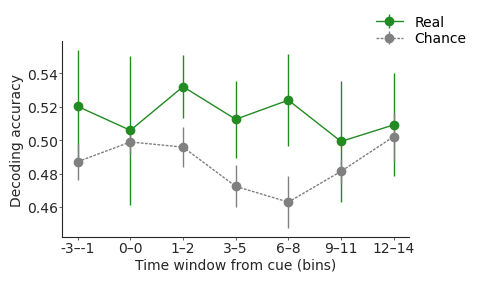

In [57]:
# Now call the function
time_windows_offset = [[x - pre_cue_window for x in sublist] for sublist in time_windows]

fig = plot_time_window_decoding(
    accuracy=all_acc,
    accuracy_chance=all_chance,
    time_windows=time_windows_offset
)

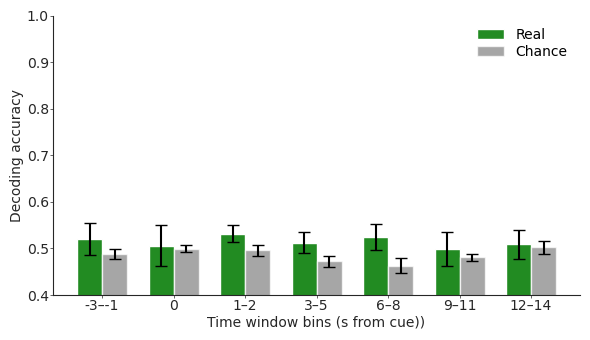

In [58]:
fig = plot_time_window_decoding_bar(
    accuracy=all_acc,
    accuracy_chance=all_chance,
    time_windows=time_windows_offset,
)

In [64]:
fig.savefig(os.path.join(result_dir, f"{decoding_pair[0]}vs{decoding_pair[1]}_timebins_LinearSVC.png"), format="png")
